# Week 2 - In Class Activity: End-to-end Machine Learning Pipeline

**Goal:** Create and end-to-end pipeline for machine learning regression models.

In this workbook, you will use a **abalone** dataset. The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope.  Other measurements, which are easier to obtain, are used to predict the age. 

By the end of the activity, you should be able to explain why:

1. Random k-fold cross-validation can leak information when nearby points or nearby months appear in both training and test folds.
2. Temporal block cross-validation better tests whether a model generalizes to unseen years.
3. Spatial block cross-validation better tests whether a model generalizes to unseen regions.
4. Blocked evaluation often gives worse, but more realistic, estimates of predictive performance.

**Dataset:**  Warwick J Nash, Tracy L Sellers, Simon R Talbot, Andrew J Cawthorn and
Wes B Ford (1994) "The Population Biology of Abalone (_Haliotis_
species) in Tasmania. I. Blacklip Abalone (_H. rubra_) from the North
Coast and Islands of Bass Strait", Sea Fisheries Division, Technical
Report No. 48 (ISSN 1034-3288)


## 1. Setup

Run the cell below. If any package is missing, uncomment the install line and run it once.

This notebook intentionally gives you some complete code and some incomplete code. Sections marked **TODO** are places where you should write or modify code yourself.

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

## 2. Load the data

In [2]:
dataset = pd.read_csv(
    '/Users/dybl4375/Documents/Teaching/GEOL 599 - Machine Learning/Machine_Learning_Course_Code_and_Data/Data/abalone.csv',
    header=None,
    names=["sex", "length", "diameter", "height", "whole_weight", "shucked_weight", "viscera_weight", "shell_weight", "rings"]
)
dataset

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


## 3. Data exploration

Before fitting a model, we explore the dataset so we understand what each variable represents and what data types are there.

In [3]:
display(dataset.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sex,4177,3,M,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
length,4177.0,NaN,NaN,NaN,0.523992,0.120093,0.075,0.45,0.545,0.615,0.815
diameter,4177.0,NaN,NaN,NaN,0.407881,0.09924,0.055,0.35,0.425,0.48,0.65
height,4177.0,NaN,NaN,NaN,0.139516,0.041827,0.0,0.115,0.14,0.165,1.13
whole_weight,4177.0,NaN,NaN,NaN,0.828742,0.490389,0.002,0.4415,0.7995,1.153,2.8255
shucked_weight,4177.0,NaN,NaN,NaN,0.359367,0.221963,0.001,0.186,0.336,0.502,1.488
viscera_weight,4177.0,NaN,NaN,NaN,0.180594,0.109614,0.0005,0.0935,0.171,0.253,0.76
shell_weight,4177.0,NaN,NaN,NaN,0.238831,0.139203,0.0015,0.13,0.234,0.329,1.005
rings,4177.0,NaN,NaN,NaN,9.933684,3.224169,1.0,8.0,9.0,11.0,29.0


In [4]:
# Determine the number of missing values
dataset.isna().sum().sort_values(ascending=False)

sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64

In [5]:
# Determine the column types
dataset.dtypes

sex                   str
length            float64
diameter          float64
height            float64
whole_weight      float64
shucked_weight    float64
viscera_weight    float64
shell_weight      float64
rings               int64
dtype: object

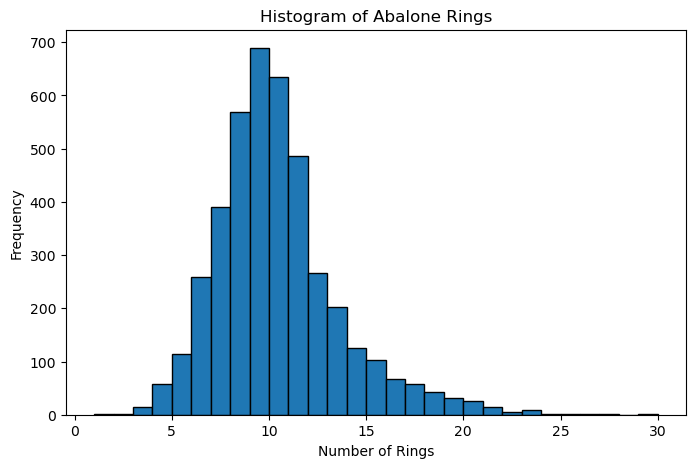

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(
    dataset["rings"],
    bins=range(dataset["rings"].min(), dataset["rings"].max() + 2),
    edgecolor="black"
)

plt.xlabel("Number of Rings")
plt.ylabel("Frequency")
plt.title("Histogram of Abalone Rings")

plt.show()

## 4. Model preprocessing and regression

We now build a simple model for number of abalone rings.

The response variable is `rings`.
    
The predictors are:

	Name		Data Type	Meas.	Description
	----		---------	-----	-----------
	Sex		nominal			M, F, and I (infant)
	Length		continuous	mm	Longest shell measurement
	Diameter	continuous	mm	perpendicular to length
	Height		continuous	mm	with meat in shell
	Whole weight	continuous	grams	whole abalone
	Shucked weight	continuous	grams	weight of meat
	Viscera weight	continuous	grams	gut weight (after bleeding)
	Shell weight	continuous	grams	after being dried

In [7]:
# Create copy of dataset
df = dataset.copy()

In [8]:
# Separate predictors and target
X = df.drop(columns=["rings"])
y = df["rings"]

### Feature Engineering

This creates new features based on other features.

In [9]:
eps = 1e-6 # Prevent infinity

# Shape proxies
X["volume_proxy"] = X["length"] * X["diameter"] * X["height"]

# Composition ratios
X["shell_to_whole"] = X["shell_weight"] / (X["whole_weight"] + eps)
X["weight_per_size"] = X["whole_weight"] / (X["volume_proxy"] + eps)

# Density-like and residual-weight features
X["nonmeat_weight"] = X["whole_weight"] - X["shucked_weight"] - X["viscera_weight"]

X.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,volume_proxy,shell_to_whole,weight_per_size,nonmeat_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,0.015777,0.291828,32.576748,0.1885
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,0.008347,0.310420,27.010840,0.0775
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,0.030051,0.310192,22.527619,0.2790
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,0.020075,0.300387,25.702331,0.1865
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,0.006732,0.268291,30.447052,0.0760


### Build the `scikit-learn` preprocessing pipeline
The pipeline separates numeric and categorical variables.

For the numeric variables, the workflow imputes missing values (although there are none here) with the median and standardizes the values.

For categorical variables, the workflow fills missing values with the most common category and then one-hot encodes the categories. `drop="first"` removes one category from each categorical variable so the regression has a reference category.

In [11]:
numeric_features = X.drop(columns = ["sex"]).columns
categorical_features = ["sex"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# Model
rf = RandomForestRegressor(criterion="poisson", random_state=42)

model_cv = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])

# Hyperparameter grid
param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [2, 4, 8],
    "model__max_features": [0.5, 1.0]
}

# Stratifying continuous targets directly is not possible, so use quantile bins.
# This helps keep rare high-ring observations represented in both partitions.
ring_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=ring_bins
)

### Cross-validation

Cross-validation gives a more realistic estimate of predictive performance. The dataset is split into five parts. The model is trained on four parts and tested on the remaining part, repeated five times.

In [12]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid search
grid_search = GridSearchCV(
    estimator=model_cv,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Fit cross-validated model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV RMSE:")
print(-grid_search.best_score_)

# Test-set predictions
y_pred = best_model.predict(X_test)

# Test-set evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nTest set performance:")
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters:
{'model__max_depth': 10, 'model__max_features': 0.5, 'model__min_samples_leaf': 8, 'model__min_samples_split': 2, 'model__n_estimators': 500}
Best CV RMSE:
2.0932887846786032

Test set performance:
Mean Absolute Error: 1.5171069566531326
Root Mean Squared Error: 2.112905277956768
R² Score: 0.5826259422166293


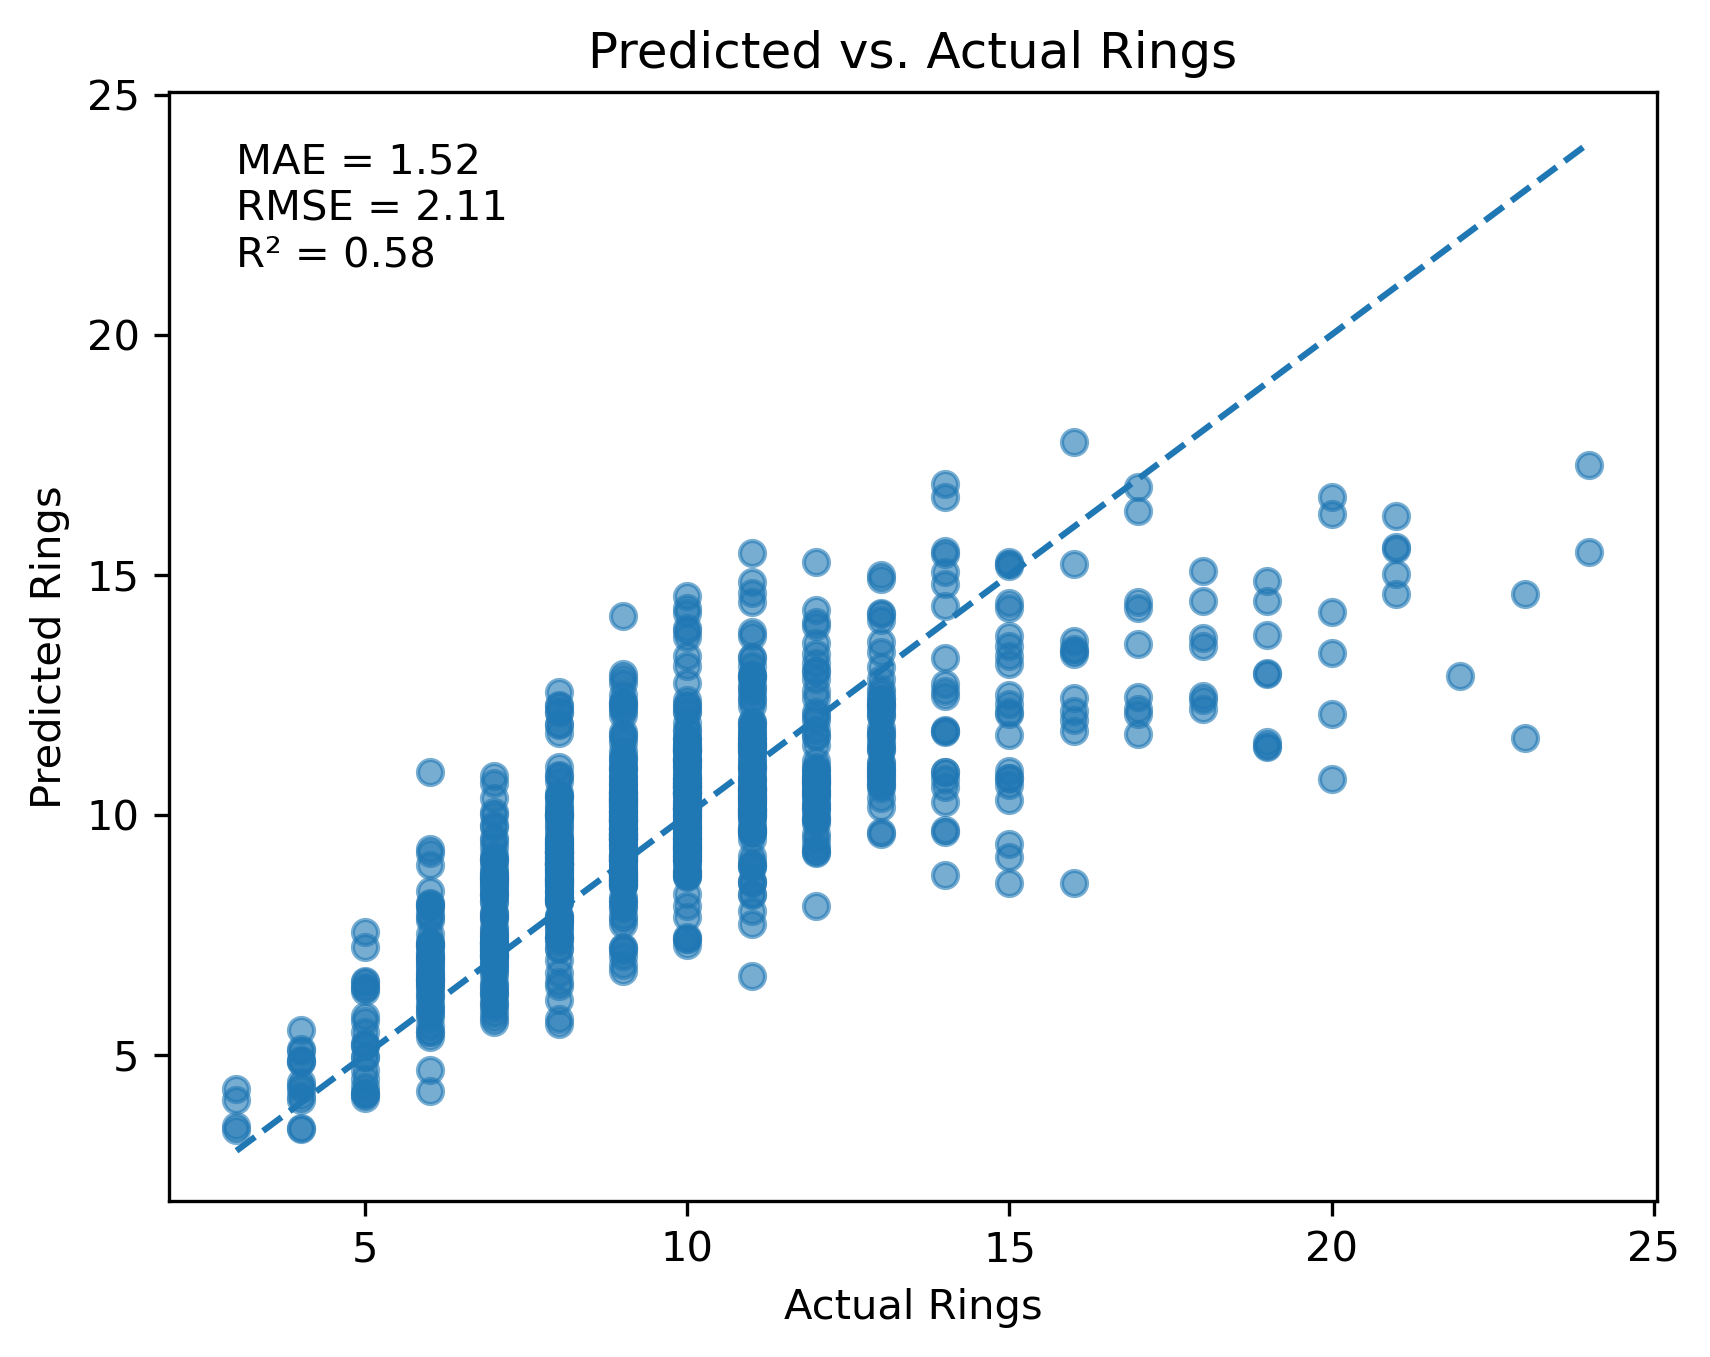

In [13]:
plt.figure(dpi=300)

plt.scatter(y_test, y_pred, alpha=0.6)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Predicted vs. Actual Rings")

plt.text(
    min_value,
    max_value,
    f"MAE = {mae:.2f}\nRMSE = {rmse:.2f}\nR² = {r2:.2f}",
    verticalalignment="top"
)

plt.show()

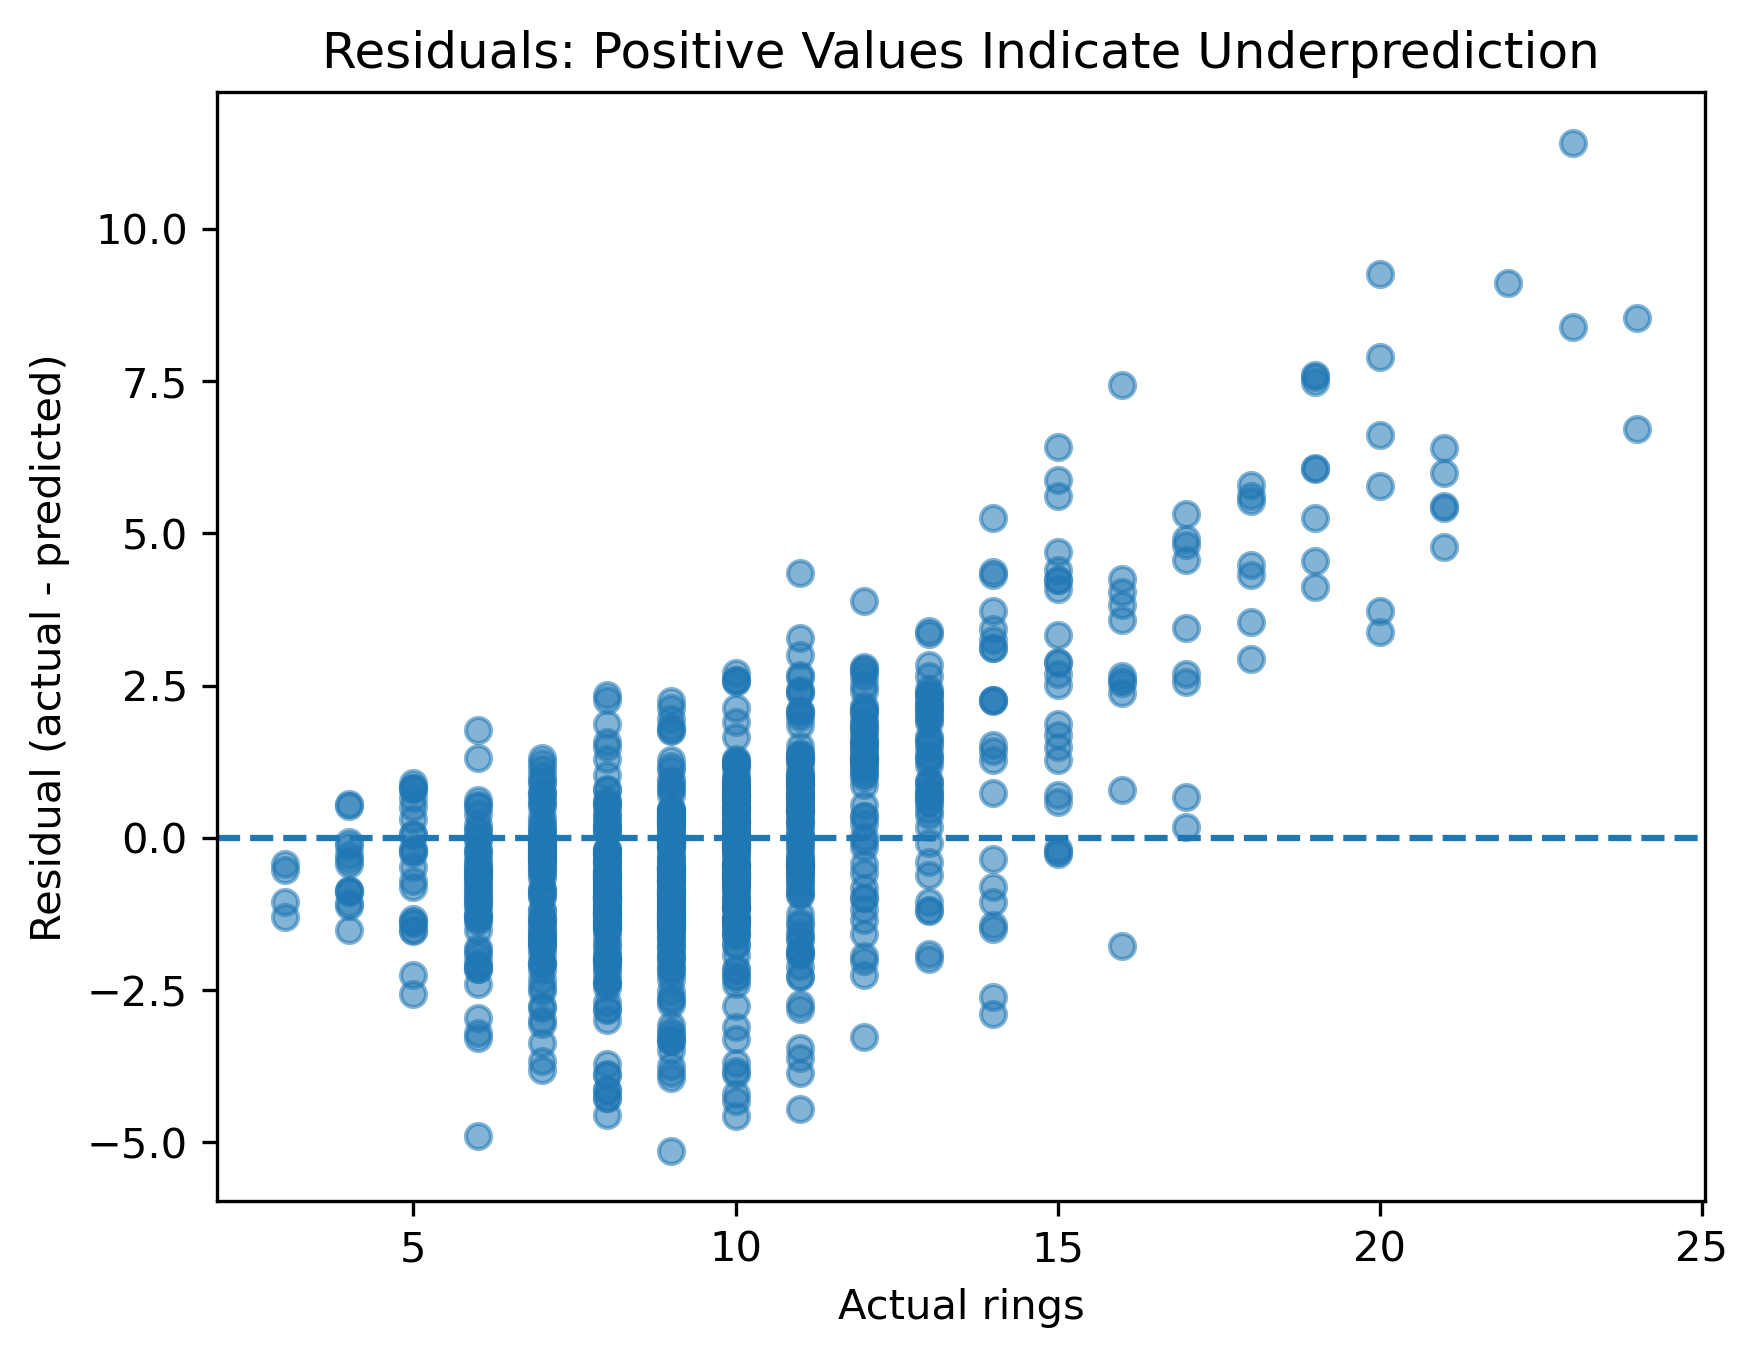

In [14]:
results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
})
results["residual"] = results["actual"] - results["predicted"]

plt.figure(dpi = 300)
plt.scatter(results["actual"], results["residual"], alpha=0.55)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual rings")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals: Positive Values Indicate Underprediction")
plt.show()

### Feature Importance

This is an indication of what provided the machine learning model the most useful information during training. We will talk about in more detail later in the semester.

,feature,importance_mean,importance_std
11,nonmeat_weight,0.493380,0.027776
5,shucked_weight,0.136451,0.008627
7,shell_weight,0.084903,0.011088
9,shell_to_whole,0.048905,0.006621
0,sex,0.019143,0.003656
8,volume_proxy,0.011491,0.003059
1,length,0.010156,0.002113
3,height,0.009228,0.003083
6,viscera_weight,0.007959,0.001151
2,diameter,0.004715,0.001148


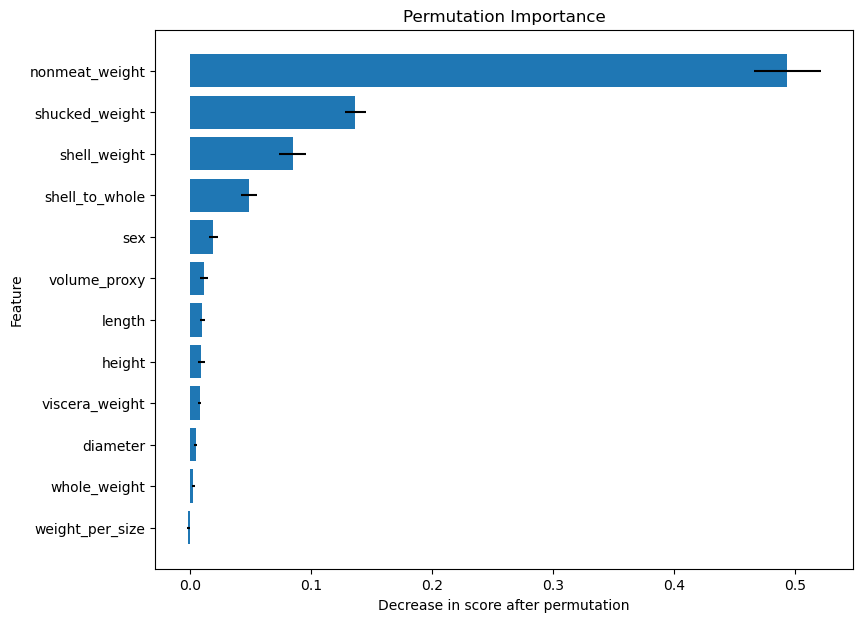

In [15]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=True)

display(importance.sort_values("importance_mean", ascending=False).head(15))

plt.figure(figsize=(9, 7))
plt.barh(
    importance["feature"],
    importance["importance_mean"],
    xerr=importance["importance_std"],
)
plt.xlabel("Decrease in score after permutation")
plt.ylabel("Feature")
plt.title("Permutation Importance")
plt.show()